In [1]:

# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
from h5py import File

import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

%load_ext autoreload
%autoreload 2

SPEED_OF_LIGHT = 299_792.458
cosmo = FlatLambdaCDM(H0=100, Om0=0.3)

### Read in the data

In [2]:
with File("/mnt/extraspace/rstiskalek/catalogs/PV/CF4/SDSS-FP.hdf5", 'r') as f:
    rmag = f["rmag"][...]
    ermag = f["ermag"][...]
    zcmb = f["gczcmb"][...] / SPEED_OF_LIGHT
    Ar = f["Exr"][...]
    kr = f["kcr"][...]


rmag_corrected = rmag + 0.85 * zcmb - Ar - kr


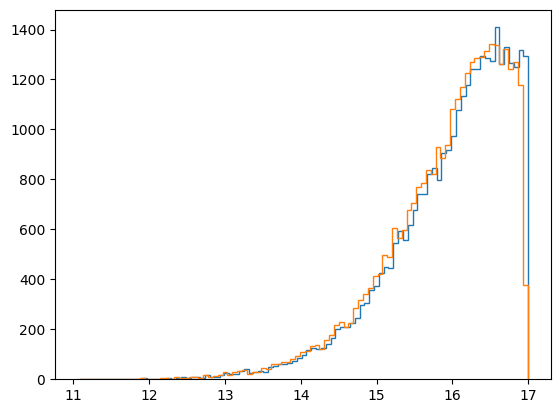

In [3]:
plt.figure()
plt.hist(rmag, bins="auto", histtype='step', label='rmag')
plt.hist(rmag_corrected, bins="auto", histtype='step', label='rmag_corrected')

plt.show()